# regime analysis

In [5]:
using JLD2
using Plots
using Statistics
using Printf

gr()
default(size=(900, 500))

const ROOT = normpath(joinpath(@__DIR__, ".."))
const SITES = ["lat30lon-50", "lat-25lon-10", "lat-45lon80", "lat0lon-140", "lat30lon-150", "lat40lon-25"]
const SITE_LABELS = Dict(
    "lat30lon-50"  => "N. Atl. subtrop",
    "lat-25lon-10" => "S. Atl. subtrop",
    "lat-45lon80"  => "S. Ind. ACC",
    "lat0lon-140"  => "Equatorial Pac",
    "lat30lon-150" => "N. Pac. subtrop",
    "lat40lon-25"  => "N. Atl. mid-lat",
)

function load_site_data(site::String)
    qt_f = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    gly_f = site == "lat30lon-50" ?
        joinpath(ROOT, "data/generated/glorys_processed.jld2") :
        joinpath(ROOT, "data/generated/glorys_processed_$(site).jld2")
    (isfile(qt_f) && isfile(gly_f)) || return nothing
    (sim=JLD2.load(qt_f), gly=JLD2.load(gly_f))
end

load_site_data (generic function with 1 method)

## per site RMSE

In [6]:
function site_rmse(site::String)
    d = load_site_data(site)
    d === nothing && return nothing
    sim, gly = d.sim, d.gly
    N = min(length(sim["T_profiles"]), length(gly["T_profiles"]))
    T_sim = [p[end] for p in sim["T_profiles"][1:N]]
    u_sim = [p[end] for p in sim["u_profiles"][1:N]]
    v_sim = [p[end] for p in sim["v_profiles"][1:N]]
    T_gly = [p[1]   for p in gly["T_profiles"][1:N]]
    u_gly = [p[1]   for p in gly["u_profiles"][1:N]]
    v_gly = [p[1]   for p in gly["v_profiles"][1:N]]
    rmse(x, y) = sqrt(mean((x .- y).^2))
    return (T=rmse(T_sim, T_gly), u=rmse(u_sim, u_gly), v=rmse(v_sim, v_gly))
end

println(rpad("site", 14), rpad("label", 20), rpad("T RMSE (°C)", 14), rpad("u RMSE", 12), "v RMSE")
println("-" ^ 72)
rows = []
for site in SITES
    r = site_rmse(site)
    r === nothing && continue
    push!(rows, (site=site, r...))
    @printf("%-14s %-20s %-14.3f %-12.4f %.4f\n",
            site, SITE_LABELS[site], r.T, r.u, r.v)
end

site          label               T RMSE (°C)   u RMSE      v RMSE
------------------------------------------------------------------------
lat30lon-50    N. Atl. subtrop      0.208          0.0785       0.1152
lat-25lon-10   S. Atl. subtrop      1.020          0.1199       0.0908
lat-45lon80    S. Ind. ACC          1.978          0.1601       0.2602
lat0lon-140    Equatorial Pac       0.763          1.2499       0.3843
lat30lon-150   N. Pac. subtrop      0.678          0.1444       0.1703
lat40lon-25    N. Atl. mid-lat      0.574          0.1292       0.0897


## non locality ratio

In [7]:
# quick heuristic: ratio of |ΔT_GLORYS over 30d| to |ΔT_sim over 30d|
# high ratio = GLORYS has more variability than the sim can produce = non-local processes dominant
function regime_ratio(site::String)
    d = load_site_data(site)
    d === nothing && return nothing
    sim, gly = d.sim, d.gly
    N = min(length(sim["T_profiles"]), length(gly["T_profiles"]))
    T_sim = [p[end] for p in sim["T_profiles"][1:N]]
    T_gly = [p[1]   for p in gly["T_profiles"][1:N]]
    return std(T_gly) / max(std(T_sim), 1e-6)
end

println(rpad("site", 14), rpad("label", 20), "std(GLORYS)/std(sim)")
println("-" ^ 55)
for site in SITES
    r = regime_ratio(site)
    r === nothing && continue
    interp = r < 1.5 ? "1-D OK" : (r < 4 ? "mixed" : "non-local dominant")
    @printf("%-14s %-20s %.2f  (%s)\n", site, SITE_LABELS[site], r, interp)
end

site          label               std(GLORYS)/std(sim)
-------------------------------------------------------
lat30lon-50    N. Atl. subtrop      0.80  (1-D OK)
lat-25lon-10   S. Atl. subtrop      3.15  (mixed)
lat-45lon80    S. Ind. ACC          3.07  (mixed)
lat0lon-140    Equatorial Pac       0.68  (1-D OK)
lat30lon-150   N. Pac. subtrop      1.58  (mixed)
lat40lon-25    N. Atl. mid-lat      0.69  (1-D OK)


## regime scatter

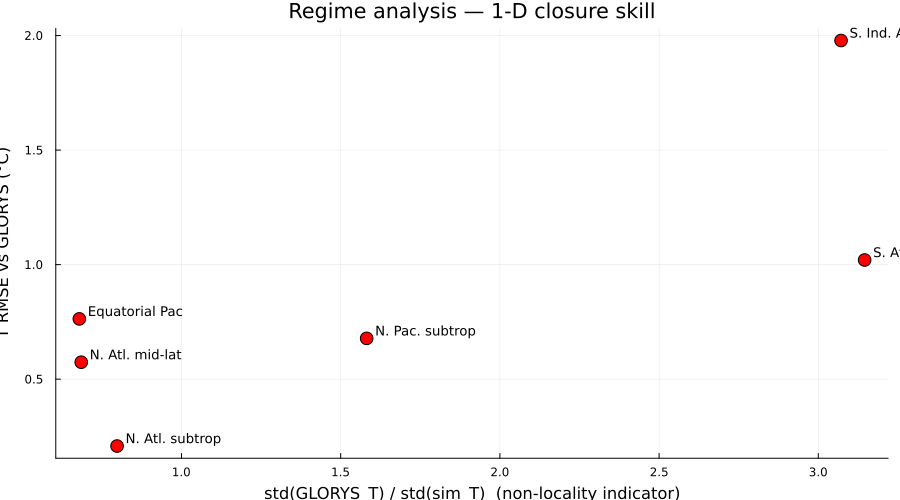

In [8]:
xs = Float64[]
ys = Float64[]
labels = String[]
for site in SITES
    r = site_rmse(site)
    rr = regime_ratio(site)
    (r === nothing || rr === nothing) && continue
    push!(xs, rr); push!(ys, r.T); push!(labels, SITE_LABELS[site])
end

scatter(xs, ys, label=nothing, xlabel="std(GLORYS_T) / std(sim_T)  (non-locality indicator)",
        ylabel="T RMSE vs GLORYS (°C)", title="Regime analysis — 1-D closure skill",
        markersize=7, color=:red)
for (x, y, lab) in zip(xs, ys, labels)
    annotate!(x, y, text("  " * lab, 9, :left, :bottom))
end
plot!()